# 01 · Quiénes son estos pacientes: cohorte, demografía y hospital A vs B

**Fase CRISP-DM: Comprensión de los datos.**

El notebook `00_carga_consolidacion` dejó lista `data/interim/cohorte_horaria.parquet`, ya
auditada: 1.552.210 filas-hora, 40.336 pacientes, sin huecos en el reloj y sin valores
imposibles. Aquí no volvemos a tocar los `.psv`; partimos de ese archivo.

La pregunta de este notebook es sencilla de enunciar pero decide buena parte del proyecto:
**¿a quién estamos tratando de predecir, y los dos hospitales nos están dando la misma
población?** Si A y B son sitios distintos con pacientes distintos, cualquier modelo que
mezcle ambos sin cuidado corre el riesgo de aprender el hospital en vez de aprender la sepsis.

Además de la cohorte y la demografía, en este notebook adelantamos tres preguntas que
normalmente se dejarían para más adelante, porque son imposibles de separar de "quiénes son
estos pacientes": cuántos datos faltan y por qué (Sección 7), qué patrón sigue esa ausencia
en el tiempo (Sección 8) y cómo evolucionan los signos vitales antes de que se declare la
sepsis (Sección 9). Un análisis exploratorio más formal y exhaustivo de estos tres temas
llegará en los notebooks 02 y 03 — aquí los dejamos planteados con evidencia real.

### Diccionario de datos

**Signos vitales** — se miden con monitor, casi cada hora (baja proporción de nulos):

| Variable | Qué mide | Unidad |
|---|---|---|
| HR | Frecuencia cardiaca | latidos/min |
| O2Sat | Saturación de oxígeno por pulsioximetría | % |
| Temp | Temperatura corporal | °C |
| SBP | Presión arterial sistólica | mmHg |
| MAP | Presión arterial media | mmHg |
| DBP | Presión arterial diastólica | mmHg |
| Resp | Frecuencia respiratoria | resp/min |
| EtCO2 | CO₂ al final de la espiración (capnografía) | mmHg |

**Laboratorios** — se piden bajo orden médica puntual, por eso son mayoritariamente nulos
(90–99,9% según vimos en el notebook 00):

| Variable | Qué mide | Unidad |
|---|---|---|
| BaseExcess | Exceso de base (gasometría arterial) | mEq/L |
| HCO3 | Bicarbonato sérico | mmol/L |
| FiO2 | Fracción inspirada de oxígeno (soporte ventilatorio) | proporción (0–1) |
| pH | pH arterial | — |
| PaCO2 | Presión parcial de CO₂ en sangre arterial | mmHg |
| SaO2 | Saturación de oxígeno arterial (gasometría, no pulsioximetría) | % |
| AST | Aspartato aminotransferasa (función hepática) | UI/L |
| BUN | Nitrógeno ureico en sangre (función renal) | mg/dL |
| Alkalinephos | Fosfatasa alcalina (función hepática) | UI/L |
| Calcium | Calcio sérico | mg/dL |
| Chloride | Cloro sérico | mmol/L |
| Creatinine | Creatinina sérica (función renal) | mg/dL |
| Bilirubin_direct | Bilirrubina directa (función hepática) | mg/dL |
| Glucose | Glucosa sérica | mg/dL |
| Lactate | Lactato sérico — marcador clásico de hipoperfusión/shock | mmol/L |
| Magnesium | Magnesio sérico | mmol/L |
| Phosphate | Fosfato sérico | mg/dL |
| Potassium | Potasio sérico | mmol/L |
| Bilirubin_total | Bilirrubina total (función hepática) | mg/dL |
| TroponinI | Troponina I (daño miocárdico) | ng/mL |
| Hct | Hematocrito | % |
| Hgb | Hemoglobina | g/dL |
| PTT | Tiempo parcial de tromboplastina (coagulación) | segundos |
| WBC | Leucocitos totales (respuesta inflamatoria/infecciosa) | 10³/µL |
| Fibrinogen | Fibrinógeno (coagulación) | mg/dL |
| Platelets | Plaquetas (coagulación) | 10³/µL |

**Demográficas, administrativas y objetivo:**

| Variable | Descripción | Categoría |
|---|---|---|
| Age | Edad del paciente | Demográfica (años) |
| Gender | Sexo (1 = hombre, 0 = mujer) | Demográfica |
| Unit1 | Ingreso a UCI médica (MICU) | Administrativa (0/1) |
| Unit2 | Ingreso a UCI quirúrgica (SICU) | Administrativa (0/1) |
| HospAdmTime | Horas entre ingreso al **hospital** y a la **UCI** (negativo = ya estaba hospitalizado) | Administrativa (horas) |
| ICULOS | Horas desde el ingreso a UCI — el reloj del proyecto | Administrativa (horas) |
| **SepsisLabel** | 1 si el paciente cumple criterios de Sepsis-3 en esa hora, 0 si no (ya desplazada 6 h por el organizador) | **Objetivo** |

En total: 8 signos vitales + 26 laboratorios + 6 demográficas/administrativas + 1 objetivo =
**41 columnas** (más `pid` y `hosp`, que añadimos nosotros en el notebook 00 para identificar
al paciente y al hospital).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
import io_datos
import viz
from config import cargar_config

cfg = cargar_config()
df = io_datos.leer_cohorte(cfg)
viz.aplicar_estilo()
pd.set_option("display.max_columns", 50)

print(f"{len(df):,} filas-hora | {df.pid.nunique():,} pacientes")

1,552,210 filas-hora | 40,336 pacientes


## 1. La variable objetivo, en dos escalas

`SepsisLabel` se puede leer de dos formas y **no dan el mismo número**: por hora-registro
(¿esta fila concreta está dentro de la ventana de sepsis?) y por paciente (¿esta persona
desarrolló sepsis en algún momento de su estancia?). Confundir las dos escalas es un error
común: un modelo que clasifica "por hora" con 98% de accuracy no está acertando en el 98% de
los *pacientes* — puede estar fallando en todos los sépticos y aun así lucir bien.

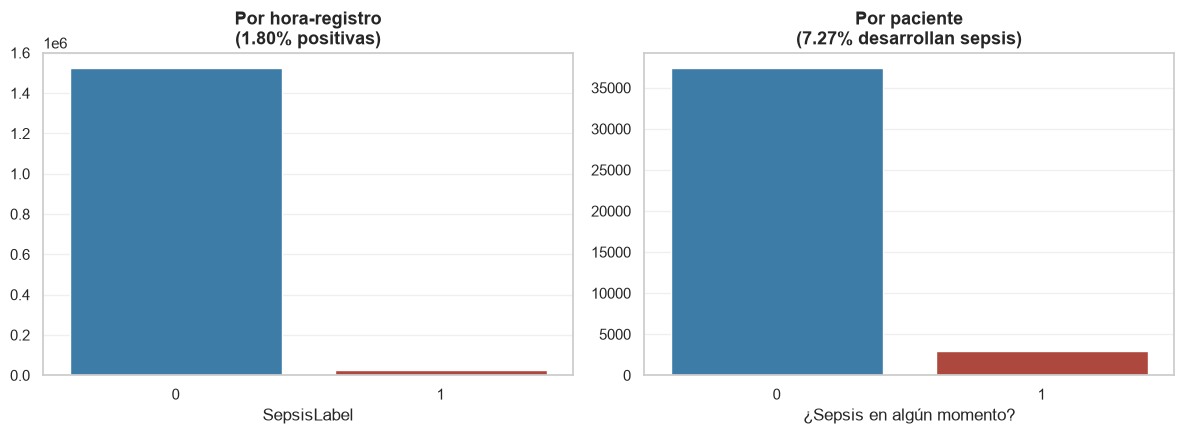

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

conteo_hora = df["SepsisLabel"].value_counts().sort_index()
sns.barplot(x=conteo_hora.index.astype(str), y=conteo_hora.values,
            hue=conteo_hora.index.astype(str), palette=[viz.COLOR_CONTROL, viz.COLOR_SEPSIS],
            legend=False, ax=axes[0])
axes[0].set_title(f"Por hora-registro\n({df.SepsisLabel.mean()*100:.2f}% positivas)")
axes[0].set_xlabel("SepsisLabel")

sepsis_pac = df.groupby("pid", observed=True)["SepsisLabel"].max()
conteo_pac = sepsis_pac.value_counts().sort_index()
sns.barplot(x=conteo_pac.index.astype(str), y=conteo_pac.values,
            hue=conteo_pac.index.astype(str), palette=[viz.COLOR_CONTROL, viz.COLOR_SEPSIS],
            legend=False, ax=axes[1])
axes[1].set_title(f"Por paciente\n({sepsis_pac.mean()*100:.2f}% desarrollan sepsis)")
axes[1].set_xlabel("¿Sepsis en algún momento?")

plt.tight_layout()
plt.show()

La diferencia es de **4x**: 1,80% de las horas están etiquetadas como sepsis, pero 7,27% de
los pacientes la desarrollan en algún momento de su estancia. Tiene sentido — cada paciente
séptico aporta muchas horas negativas (antes del evento) por cada hora positiva. Esta
asimetría es la razón por la que en el notebook 07 vamos a usar el utility score del challenge
en vez de accuracy: con un desbalance así, "no septico" es un baseline que acierta el 98,2%
de las horas sin haber aprendido nada.

### ¿Es igual en los dos hospitales?

In [3]:
prev_hora = df.groupby("hosp", observed=True)["SepsisLabel"].mean() * 100
prev_pac = (df.groupby(["hosp", "pid"], observed=True)["SepsisLabel"].max()
            .groupby("hosp", observed=True).mean() * 100)

resumen_prev = pd.DataFrame({"prevalencia_hora_%": prev_hora.round(2),
                             "prevalencia_paciente_%": prev_pac.round(2)})
resumen_prev

,prevalencia_hora_%,prevalencia_paciente_%
hosp,,
A,2.17,8.80
B,1.41,5.71


No es igual: el hospital **A tiene 8,80%** de pacientes sépticos y el **B solo 5,71%** — una
diferencia relativa del 54%. No sabemos todavía si es porque A recibe pacientes más graves,
porque codifica la sepsis de forma distinta, o porque su población es distinta (lo vamos a
poder acotar con lo que sigue). Lo que sí es seguro es que **un modelo entrenado ignorando el
hospital va a promediar dos realidades distintas**, y eso es exactamente lo que vamos a poner
a prueba entrenando en A y validando en B en el notebook 06.

## 2. Demografía: edad y género

Trabajamos a nivel paciente (`Age` y `Gender` son constantes por persona, según verificamos
en el notebook 00), no a nivel hora — repetir la edad de un paciente 40 veces solo inflaría
artificialmente el tamaño de muestra sin aportar información nueva.

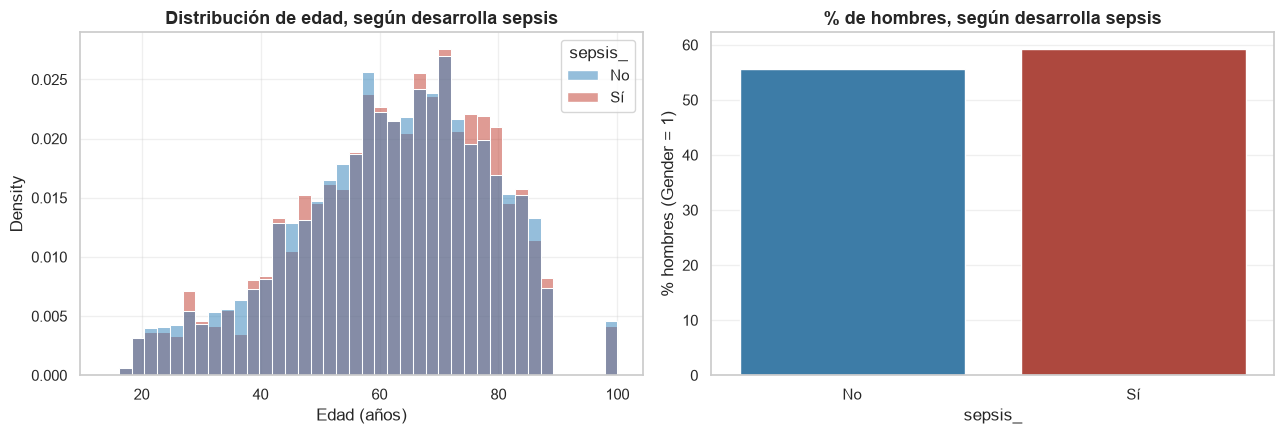

Edad: mediana {'No': 63.0, 'Sí': 64.0}
% hombres: {'No': 55.70000076293945, 'Sí': 59.29999923706055}


In [4]:
pac = df.groupby("pid", observed=True).agg(
    hosp=("hosp", "first"), edad=("Age", "first"), genero=("Gender", "first"),
    hosp_adm=("HospAdmTime", "first"), los=("ICULOS", "max"), sepsis=("SepsisLabel", "max"),
    unit1=("Unit1", "first"),
)
pac["sepsis_"] = pac["sepsis"].map({0: "No", 1: "Sí"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=pac, x="edad", hue="sepsis_", bins=40, palette=[viz.COLOR_CONTROL, viz.COLOR_SEPSIS],
             stat="density", common_norm=False, alpha=0.5, ax=axes[0])
axes[0].set_title("Distribución de edad, según desarrolla sepsis")
axes[0].set_xlabel("Edad (años)")

genero_sep = pac.groupby(["sepsis_"])["genero"].mean() * 100
sns.barplot(x=genero_sep.index, y=genero_sep.values, hue=genero_sep.index,
            palette=[viz.COLOR_CONTROL, viz.COLOR_SEPSIS], legend=False, ax=axes[1])
axes[1].set_title("% de hombres, según desarrolla sepsis")
axes[1].set_ylabel("% hombres (Gender = 1)")

plt.tight_layout()
plt.show()

print("Edad: mediana", pac.groupby("sepsis_").edad.median().round(1).to_dict())
print("% hombres:", genero_sep.round(1).to_dict())

La edad **casi no separa los grupos** (mediana 63 vs 64 años — un año de diferencia, dentro
del ruido) y el género aporta algo más: 59,3% de hombres entre los sépticos frente a 55,7%
entre los que no, una diferencia de apenas 3,6 puntos. Ninguna de las dos parece ser una
variable fuerte por sí sola. Esto no es un fracaso del análisis — es información real: nos
dice que **no hay un perfil demográfico obvio de "paciente en riesgo"**, y que la señal va a
tener que venir de la fisiología (los signos vitales y labs), no de quién es el paciente.

## 3. Duración de estancia: la mediana engaña

Miramos cuánto tiempo pasan los pacientes en UCI, y aquí vale la pena mirar más que el
promedio: las colas de la distribución cuentan una historia distinta al centro.

In [5]:
tabla_los = pac.groupby("sepsis_")["los"].describe(percentiles=[.5, .75, .9, .95, .99]).round(1)
tabla_los[["count", "mean", "50%", "75%", "90%", "95%", "99%", "max"]]

,count,mean,50%,75%,90%,95%,99%,max
sepsis_,,,,,,,,
No,37404.0,37.4,39.0,47.0,54.0,57.0,59.0,336.0
Sí,2932.0,59.4,38.0,82.0,143.9,192.9,264.4,336.0


La **mediana es prácticamente idéntica** (38 h sépticos vs 39 h no sépticos) — si solo
mirásemos ese número, concluiríamos que la sepsis no afecta la duración de la estancia. Pero
el **percentil 90 se dispara a 143,9 h en los sépticos frente a 54 h** en el resto, y el
percentil 99 llega a 264 h (11 días) contra 59 h. La sepsis no alarga la estancia típica; lo
que hace es **generar una cola larga de estancias muy prolongadas** en el subgrupo de
pacientes que más se complican. Visualizarlo con un boxplot sin recortar los outliers, para
que la cola se vea:

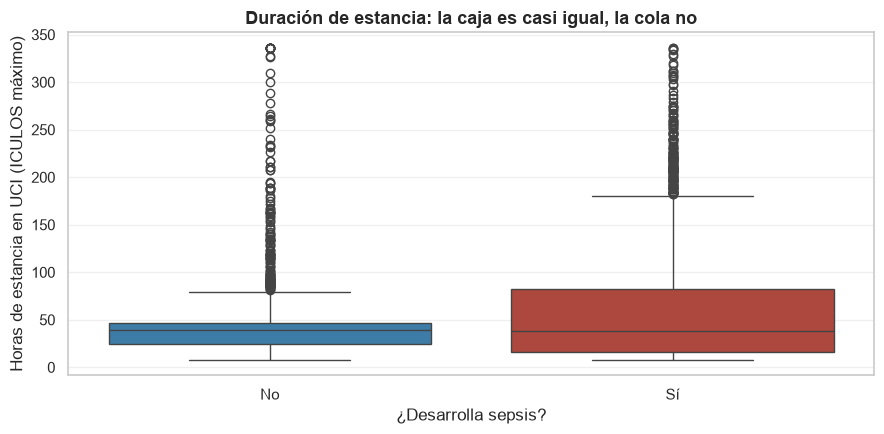

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=pac, x="sepsis_", y="los", hue="sepsis_",
            palette=[viz.COLOR_CONTROL, viz.COLOR_SEPSIS], legend=False, ax=ax)
ax.set_ylabel("Horas de estancia en UCI (ICULOS máximo)")
ax.set_xlabel("¿Desarrolla sepsis?")
ax.set_title("Duración de estancia: la caja es casi igual, la cola no")
plt.tight_layout()
plt.show()

## 4. Los relojes del proyecto: cuándo llega el paciente y cuándo aparece la sepsis

Este dataset tiene, en realidad, **tres relojes superpuestos**: cuándo ingresa al hospital,
cuándo pasa a UCI (`ICULOS = 0`), y cuándo se declara la sepsis. Vale la pena jugar con los
tres, porque su relación entre sí es tan informativa como cualquier signo vital.

### 4.1 `HospAdmTime`: ¿cuánto tiempo estuvo en piso antes de llegar a UCI?

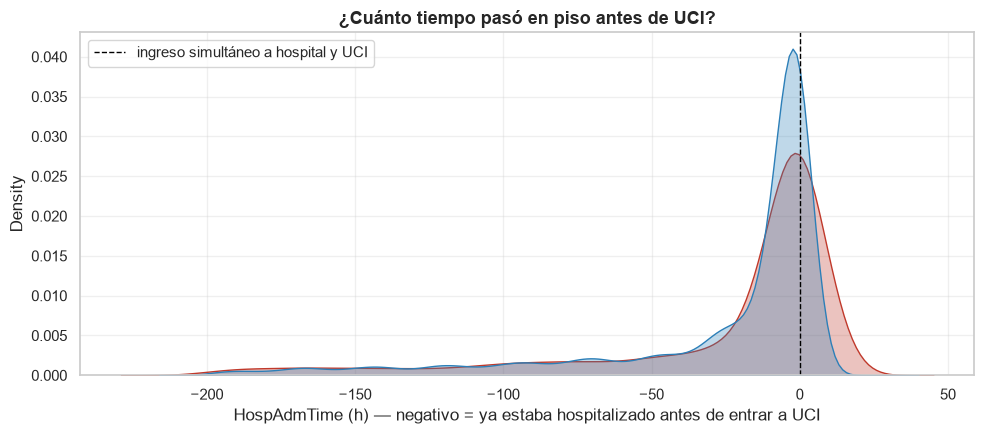

HospAdmTime mediana: {'No': -6.199999809265137, 'Sí': -2.940000057220459}
% que ingresa a UCI el mismo día del hospital (> -24h): {'No': 67.9, 'Sí': 65.3}


In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
recorte = pac[pac["hosp_adm"] > -200]  # recortamos la cola extrema (-5.367 h = 7+ meses) solo para ver la forma
sns.kdeplot(data=recorte, x="hosp_adm", hue="sepsis_", fill=True, alpha=0.3, common_norm=False,
            palette=[viz.COLOR_CONTROL, viz.COLOR_SEPSIS], ax=ax)
ax.axvline(0, color="black", ls="--", lw=1, label="ingreso simultáneo a hospital y UCI")
ax.set_xlabel("HospAdmTime (h) — negativo = ya estaba hospitalizado antes de entrar a UCI")
ax.set_title("¿Cuánto tiempo pasó en piso antes de UCI?")
ax.legend()
plt.tight_layout()
plt.show()

print("HospAdmTime mediana:", pac.groupby("sepsis_").hosp_adm.median().round(2).to_dict())
print("% que ingresa a UCI el mismo día del hospital (> -24h):",
      (pac.groupby("sepsis_").hosp_adm.apply(lambda s: (s > -24).mean() * 100)).round(1).to_dict())

Los pacientes que terminan con sepsis tienen una mediana de `HospAdmTime` de **−2,9 h frente a
−6,2 h** en el resto: llegan a la UCI *más rápido* después de su ingreso hospitalario. Es
clínicamente coherente — cuadra con dos escenarios que el dataset no distingue pero que la
literatura sí describe: pacientes que llegan ya en shock séptico directo desde urgencias, o
pacientes cuyo deterioro en piso es tan rápido que se les traslada a UCI casi de inmediato. En
ambos casos, un paciente que "salta" rápido a UCI es una señal de alerta temprana en sí misma
— y es una variable que tenemos disponible desde la hora 0, antes de cualquier signo vital.

### 4.2 ¿Cuándo, dentro de la estancia, se declara la sepsis?

La pregunta que motiva todo el proyecto: si la sepsis aparece siempre en un momento
predecible (por ejemplo, siempre en las primeras 24 h), el problema sería mucho más fácil que
si aparece en cualquier punto de la estancia.

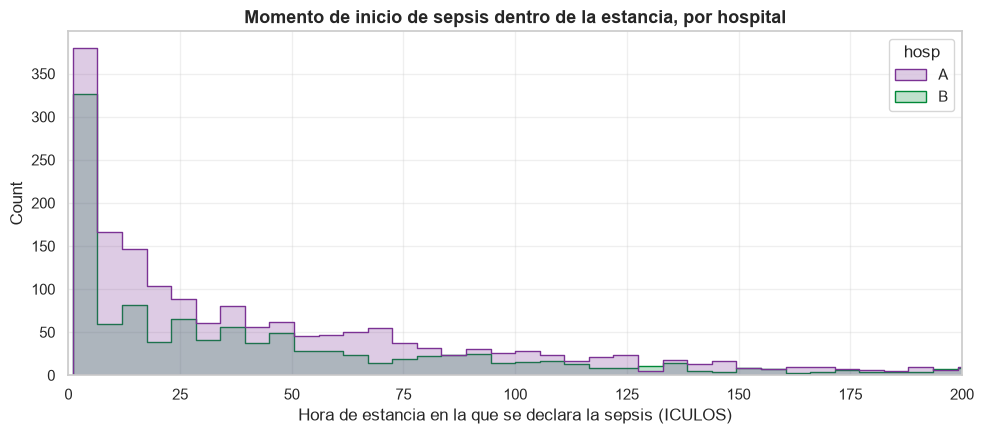

24,1% de los sépticos son etiquetados en las primeras 6h | 46,1% en las primeras 24h
mediana global: 29 h | p90: 135 h


In [8]:
onset = df.loc[df["SepsisLabel"] == 1].groupby("pid", observed=True)["ICULOS"].min()
onset = onset.to_frame("t_onset").join(pac[["hosp"]])

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(data=onset, x="t_onset", hue="hosp", bins=60, element="step",
             palette={"A": viz.COLOR_A, "B": viz.COLOR_B}, ax=ax)
ax.set_xlim(0, 200)
ax.set_xlabel("Hora de estancia en la que se declara la sepsis (ICULOS)")
ax.set_title("Momento de inicio de sepsis dentro de la estancia, por hospital")
plt.tight_layout()
plt.show()

print(f"24,1% de los sépticos son etiquetados en las primeras 6h | 46,1% en las primeras 24h")
print("mediana global:", int(onset.t_onset.median()), "h | p90:", int(onset.t_onset.quantile(.9)), "h")

No hay un momento fijo: la sepsis aparece desde la hora 1 hasta más allá de 300 h de estancia,
con una mediana de 29 h pero una cola larga. Casi la mitad (46,1%) se declara en el primer
día — coherente con lo que acabamos de ver en `HospAdmTime`: muchos pacientes llegan a UCI ya
en proceso séptico o muy cerca de estarlo. El resto se desarrolla progresivamente durante la
estancia. **Conclusión de diseño:** esto descarta cualquier enfoque que prediga "una sola vez
al ingreso" — confirma que el problema debe resolverse **hora a hora**, tal como está
planteado en el challenge, y no como una clasificación estática al inicio de la estancia.

## 5. ¿Alguna variable, por sí sola, ya nos dice si hay sepsis?

Antes de construir nada elaborado, vale la pena la pregunta más simple posible: ¿hay
correlación lineal directa entre un signo vital y `SepsisLabel`? Si la hubiera, el problema
sería trivial. Lo esperado, dada la literatura clínica, es que no —la sepsis es un síndrome
que se reconoce por la *combinación* de signos, no por uno aislado.

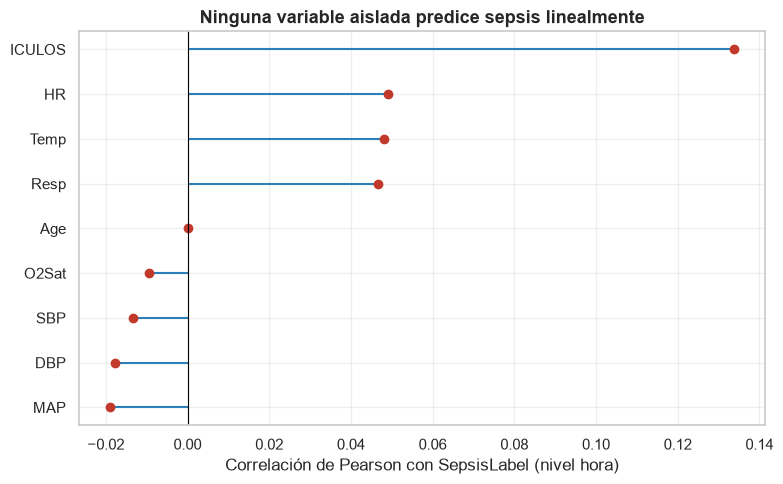

In [9]:
vitales = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]
corr = df[vitales + ["Age", "ICULOS", "SepsisLabel"]].corr()["SepsisLabel"].drop("SepsisLabel").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hlines(y=corr.index, xmin=0, xmax=corr.values, color=viz.COLOR_CONTROL)
ax.plot(corr.values, corr.index, "o", color=viz.COLOR_SEPSIS)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlación de Pearson con SepsisLabel (nivel hora)")
ax.set_title("Ninguna variable aislada predice sepsis linealmente")
plt.tight_layout()
plt.show()

Como se esperaba: la correlación más alta en magnitud es apenas **0,134, y es de `ICULOS`**
— no de un signo vital. Tiene una explicación mecánica y no clínica: cuanto más tiempo lleva
un paciente en la UCI, mayor la probabilidad acumulada de que en algún momento haya
desarrollado sepsis (es casi una función de exposición al riesgo, no una señal predictiva). De
los signos vitales, `HR` (0,049), `Temp` (0,048) y `Resp` (0,047) son los más asociados —
débiles, pero **en la dirección clínicamente esperada** (todos positivos: suben con la
sepsis), y `MAP`/`DBP`/`SBP` son negativos (bajan con la sepsis), consistente con el shock
hemodinámico. La correlación lineal es débil porque la relación no es lineal ni instantánea:
es la *tendencia* de estas variables en las horas previas la que importa, no su valor puntual
— y eso es exactamente lo que exploramos con las trayectorias alineadas al evento en el
notebook 03, y lo que capturan las features de pendiente y ventana del notebook 05.

## 5.1 Estadística descriptiva de los signos vitales

Antes de seguir a preguntas más finas, la base que suele ir primero en cualquier EDA: rango,
dispersión y outliers de las 8 variables que sí se miden con regularidad (los 26 laboratorios
tienen tanto nulo que su `describe()` a nivel hora-registro sería casi puro NaN; se retoman
uno por uno, con evidencia propia, en los notebooks 02 a 04).

In [10]:
df[vitales].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
HR,1398811.0,84.6,17.3,20.0,72.0,83.5,95.5,280.0
O2Sat,1349474.0,97.2,2.9,20.0,96.0,98.0,99.5,100.0
Temp,525224.0,37.0,0.8,20.9,36.5,37.0,37.5,42.2
SBP,1325945.0,123.8,23.2,20.0,107.0,121.0,138.0,300.0
MAP,1358739.0,82.4,16.2,20.0,71.0,80.0,92.0,250.0
DBP,1065553.0,63.8,13.8,20.0,54.0,62.0,72.0,200.0
Resp,1313825.0,18.7,5.1,1.0,15.0,18.0,21.5,79.0


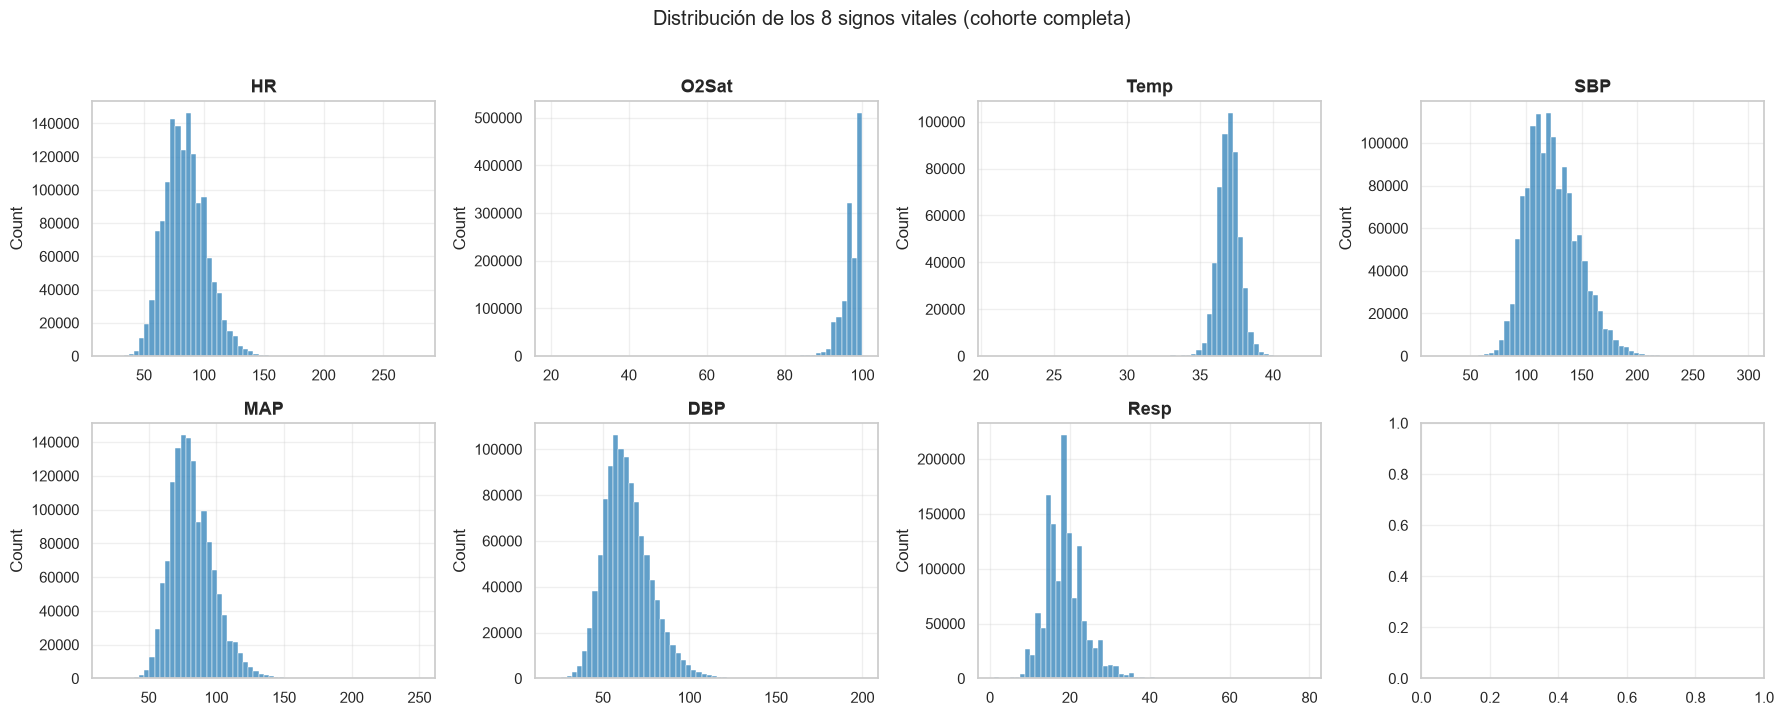

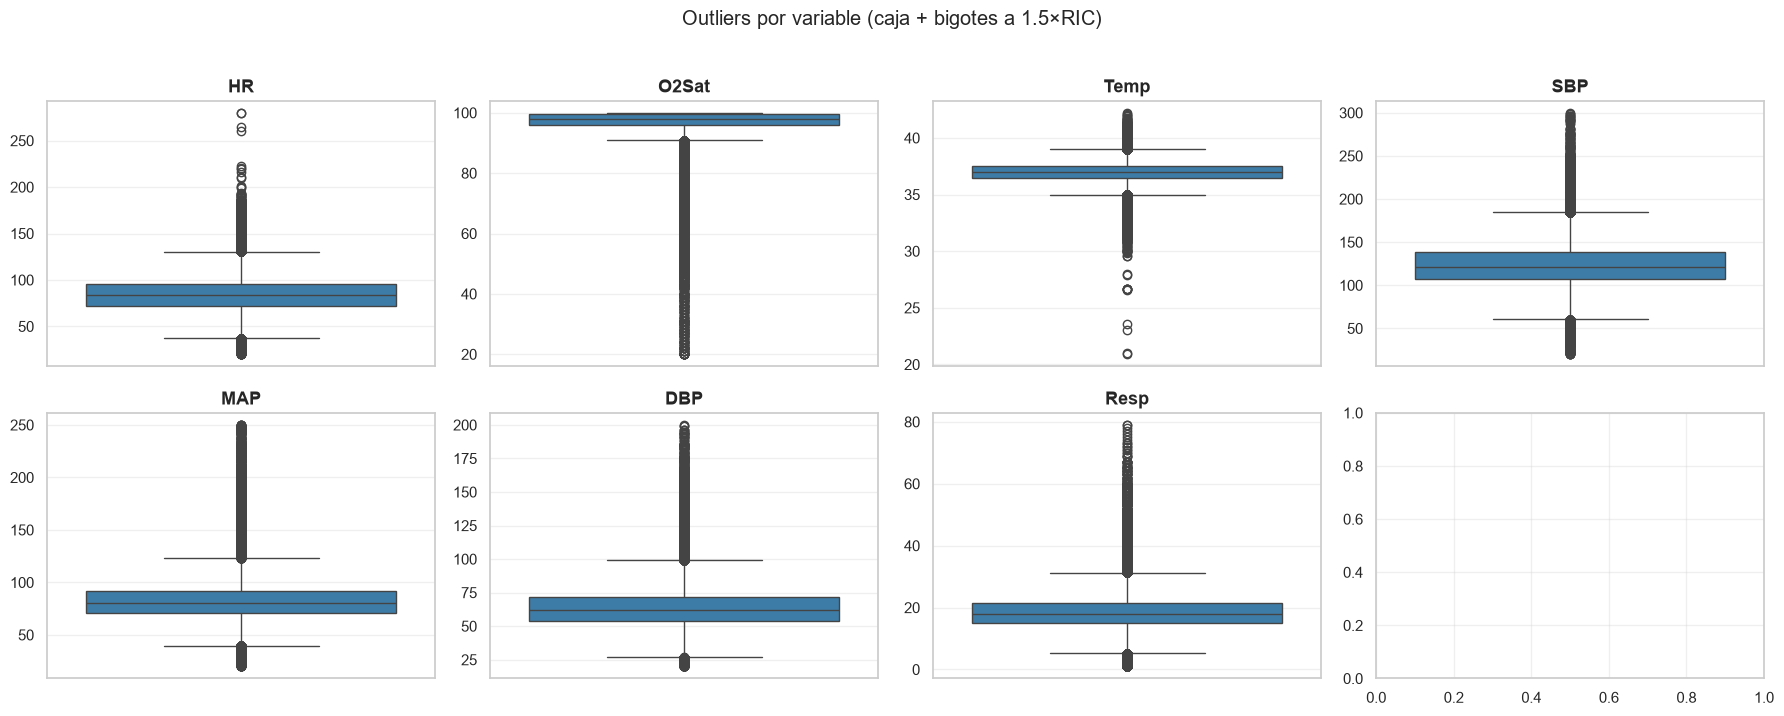

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, var in zip(axes.flat, vitales):
    sns.histplot(df[var].dropna(), bins=60, color=viz.COLOR_CONTROL, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("")
fig.suptitle("Distribución de los 8 signos vitales (cohorte completa)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, var in zip(axes.flat, vitales):
    sns.boxplot(y=df[var].dropna(), color=viz.COLOR_CONTROL, ax=ax)
    ax.set_title(var)
    ax.set_ylabel("")
fig.suptitle("Outliers por variable (caja + bigotes a 1.5×RIC)", y=1.02)
plt.tight_layout()
plt.show()

Los rangos son fisiológicamente sensatos tras la limpieza del notebook 00: `HR` con media
84,6 lpm (RIC 72–95,5), `Temp` centrada en 37,0 °C, `O2Sat` con mediana 98% y una cola larga
hacia abajo (mínimo del RIC en 96%, coherente con pacientes con compromiso respiratorio). Los
tres de presión (`SBP`/`MAP`/`DBP`) muestran la dispersión más amplia en términos absolutos,
esperable en una población de UCI con estados hemodinámicos muy distintos.

Con el criterio clásico de caja y bigotes (1,5×RIC), el porcentaje de valores fuera de rango
es bajo y parejo: entre 1,0% (`HR`) y 2,1% (`Resp`). No hay ninguna variable con una cola de
outliers desproporcionada — consistente con que el notebook 00 ya depuró los errores de
registro más groseros (temperaturas de 50 °C, presiones imposibles) y lo que queda aquí es
variabilidad clínica real, no ruido de captura.

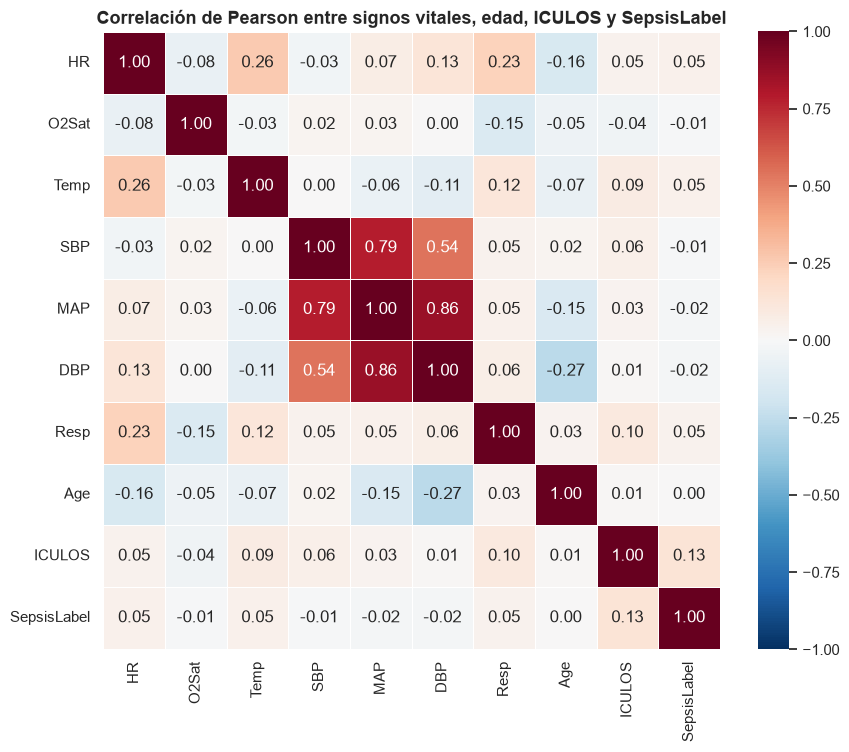

In [12]:
corr_completa = df[vitales + ["Age", "ICULOS", "SepsisLabel"]].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr_completa, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlación de Pearson entre signos vitales, edad, ICULOS y SepsisLabel")
plt.tight_layout()
plt.show()

Tres bloques se distinguen con claridad. **Presión arterial**: `SBP`-`MAP` (0,79) y
`MAP`-`DBP` (0,86) están fuertemente correlacionadas entre sí — mecánicamente esperable, `MAP`
es casi una combinación lineal de las otras dos (≈ DBP + (SBP−DBP)/3). **Edad**: correlaciona
negativo con `DBP` (−0,27) y `MAP` (−0,15) — la pérdida de elasticidad arterial con la edad es
un hallazgo fisiológico conocido, no ruido. **El resto es débil**: `HR`-`Temp` (0,26) y
`HR`-`Resp` (0,23) son las únicas correlaciones no relacionadas con presión que superan 0,2 —
coherente con que la fiebre y el compromiso respiratorio suelen acompañarse de taquicardia,
pero lejos de la redundancia que sí existe dentro del bloque de presión.

**Para el modelado (notebook 05)** esto importa de una forma específica: `SBP`, `MAP` y `DBP`
comparten información en un grado que ninguna otra pareja de vitales alcanza, así que no debe
sorprender si sus features derivadas (`_ult`, `_media_6h`, etc.) terminan entre los pares más
correlacionados de la matriz completa — no es una señal de error, es la misma redundancia
fisiológica ya vista aquí, propagada por la ingeniería de características.

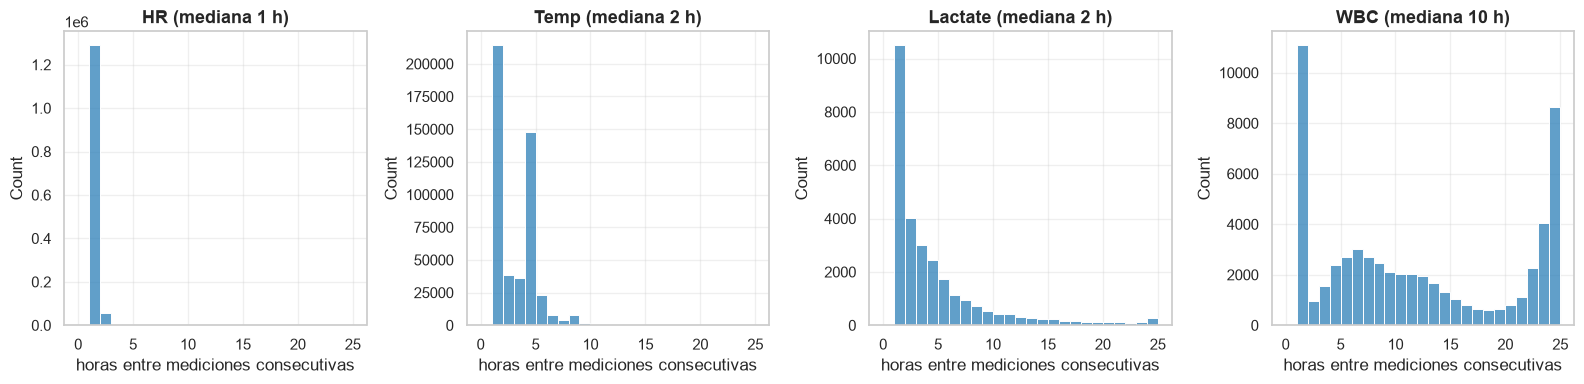

In [13]:
df_ordenado = df.sort_values(["pid", "ICULOS"])
variables_intervalo = ["HR", "Temp", "Lactate", "WBC"]  # 2 vitales, 2 laboratorios, a propósito

fig, axes = plt.subplots(1, len(variables_intervalo), figsize=(16, 4))
for ax, var in zip(axes, variables_intervalo):
    medido = df_ordenado[df_ordenado[var].notna()]
    intervalo = medido.groupby("pid", observed=True)["ICULOS"].diff()
    sns.histplot(intervalo.dropna(), bins=range(0, 26), color=viz.COLOR_CONTROL, ax=ax)
    ax.set_title(f"{var} (mediana {intervalo.median():.0f} h)")
    ax.set_xlabel("horas entre mediciones consecutivas")
plt.tight_layout()
plt.show()

La diferencia es enorme y confirma la intuición de la Sección 7. `HR` se mide casi
mecánicamente: mediana de 1 hora entre mediciones consecutivas y **92,1%** de los intervalos
caen exactamente en esa hora — es, en la práctica, un monitor continuo muestreado horariamente,
sin huecos. `Temp` ya es distinto: mediana de 2 horas y solo 40,8% a intervalos de 1 hora — se
revisa con regularidad, pero no en cada ronda. Los dos laboratorios rompen el patrón por
completo: `Lactate` tiene mediana de 2 horas cuando se pide, pero con una media (5,3 h) muy por
encima de la mediana y un P90 de 12 horas — hay una masa de pediciones rápidas seguidas de
huecos largos, coherente con que se repite mientras hay sospecha activa y luego se espacia.
`WBC` es el más disperso: mediana de **10 horas** entre mediciones, apenas 11,1% a 1 hora — se
comporta como un laboratorio de rutina diaria, no como una variable de seguimiento estrecho.

## 6. Radiografía comparada: hospital A vs B

Reunimos en un solo gráfico las diferencias que hemos ido encontrando sueltas. Un
*dumbbell chart* (dos puntos conectados por una línea) deja ver de un vistazo la magnitud de
cada brecha entre hospitales, sobre variables que ya sabemos que están en escalas distintas
— por eso cada métrica se normaliza a su propio rango antes de graficar.

In [14]:
metricas = {
    "Prevalencia de sepsis (%, paciente)": prev_pac,
    "Edad mediana (años)": pac.groupby("hosp", observed=True).edad.median(),
    "% hombres": pac.groupby("hosp", observed=True).genero.mean() * 100,
    "Estancia mediana (h)": pac.groupby("hosp", observed=True).los.median(),
    "% ingreso UCI el mismo día": pac.groupby("hosp", observed=True).hosp_adm.apply(lambda s: (s > -24).mean() * 100),
    "% con Unit1/Unit2 sin registrar (nulo)": pac.groupby("hosp", observed=True).unit1.apply(lambda s: s.isna().mean() * 100),
}
tabla_ab = pd.DataFrame(metricas).T
tabla_ab.columns = ["Hospital A", "Hospital B"]
tabla_ab.round(1)

,Hospital A,Hospital B
"Prevalencia de sepsis (%, paciente)",8.8,5.7
Edad mediana (años),64.7,62.0
% hombres,58.2,53.7
Estancia mediana (h),40.0,38.0
% ingreso UCI el mismo día,71.8,63.6
% con Unit1/Unit2 sin registrar (nulo),46.8,30.5


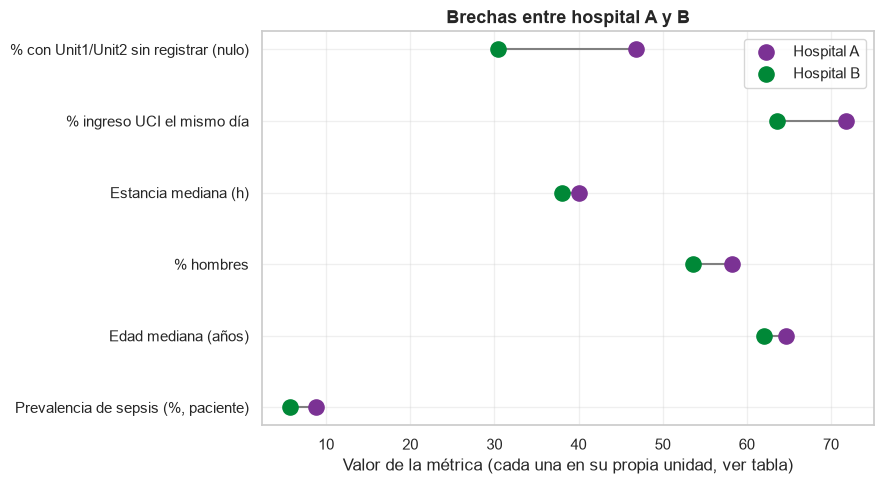

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(tabla_ab))

for i, (nombre, fila) in enumerate(tabla_ab.iterrows()):
    ax.plot([fila["Hospital A"], fila["Hospital B"]], [i, i], color="grey", lw=1.5, zorder=1)

ax.scatter(tabla_ab["Hospital A"], y, color=viz.COLOR_A, s=120, label="Hospital A", zorder=2)
ax.scatter(tabla_ab["Hospital B"], y, color=viz.COLOR_B, s=120, label="Hospital B", zorder=2)

ax.set_yticks(y)
ax.set_yticklabels(tabla_ab.index)
ax.set_xlabel("Valor de la métrica (cada una en su propia unidad, ver tabla)")
ax.set_title("Brechas entre hospital A y B")
ax.legend()
plt.tight_layout()
plt.show()

El patrón que emerge es **un solo hospital (A) sistemáticamente más "intensivo"** en lo
clínico —más prevalencia de sepsis (8,8% vs 5,7%), más edad mediana (65 vs 62 años) y más
pacientes que llegan a UCI el mismo día de su ingreso hospitalario (71,8% vs 63,6%)— pero a la
vez **el que peor registra lo administrativo**: 46,8% de sus pacientes no tienen el tipo de
unidad (`Unit1`/`Unit2`) documentado, frente a 30,5% en B; son dos procesos distintos
(gravedad clínica y disciplina de registro) que no tienen por qué ir de la mano, y en conjunto
la imagen es consistente con **dos sistemas hospitalarios reales, no con dos muestras
aleatorias del mismo proceso** — justo lo que hace interesante el problema, porque cualquier
modelo que aspire a ser útil en más de un hospital tiene que generalizar a través de este tipo
de diferencias administrativas, no solo del ruido estadístico normal.

## 7. Nulos por variable: cuánto falta y cuánto sabemos realmente

Hasta ahora hablamos de nulos de pasada (notebook 00). Aquí los mostramos completos: el
porcentaje de nulos de **cada una** de las 40 variables, no un resumen. Mostramos porcentaje y
no solo conteo crudo — con 1,55 millones de filas, un conteo aislado no dice si el problema es
grave o cosmético.

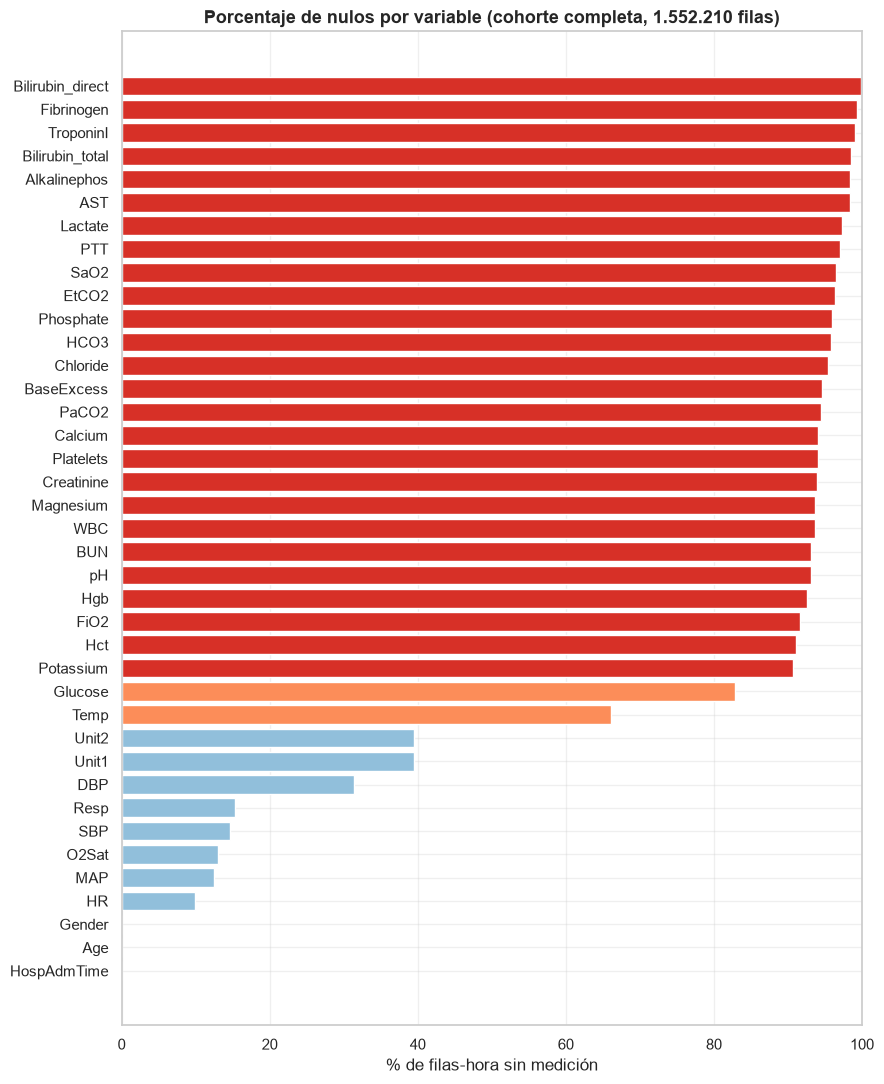

In [16]:
import features  # familias VITALES / LABORATORIOS ya definidas en src/, evita repetir la lista aquí

nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
nulos = nulos.drop(["pid", "hosp", "SepsisLabel", "ICULOS"])  # completas por construcción

fig, ax = plt.subplots(figsize=(9, 11))
viz.barras_nulos(nulos, "Porcentaje de nulos por variable (cohorte completa, 1.552.210 filas)", ax=ax)
plt.tight_layout()
plt.show()

Tres franjas, tres estrategias distintas de tratamiento que retomamos en los notebooks 02 y
04: **azul (<50%)** son los signos vitales y `Unit1`/`Unit2`, donde un arrastre simple del
último valor va a bastar; **naranja (50–90%)** son solo `Temp` (66%) y `Glucose` (83%); y
**rojo (>90%)** son 24 de los 26 laboratorios, donde ninguna imputación va a "rellenar" el
hueco de forma honesta.

Ahora la misma información mirada al revés: no cuánto falta, sino **cuánto sabemos
realmente, en promedio, de cada paciente**. Contamos mediciones absolutas por paciente (no
proporciones), para ver el volumen real de datos con el que trabaja el modelo.

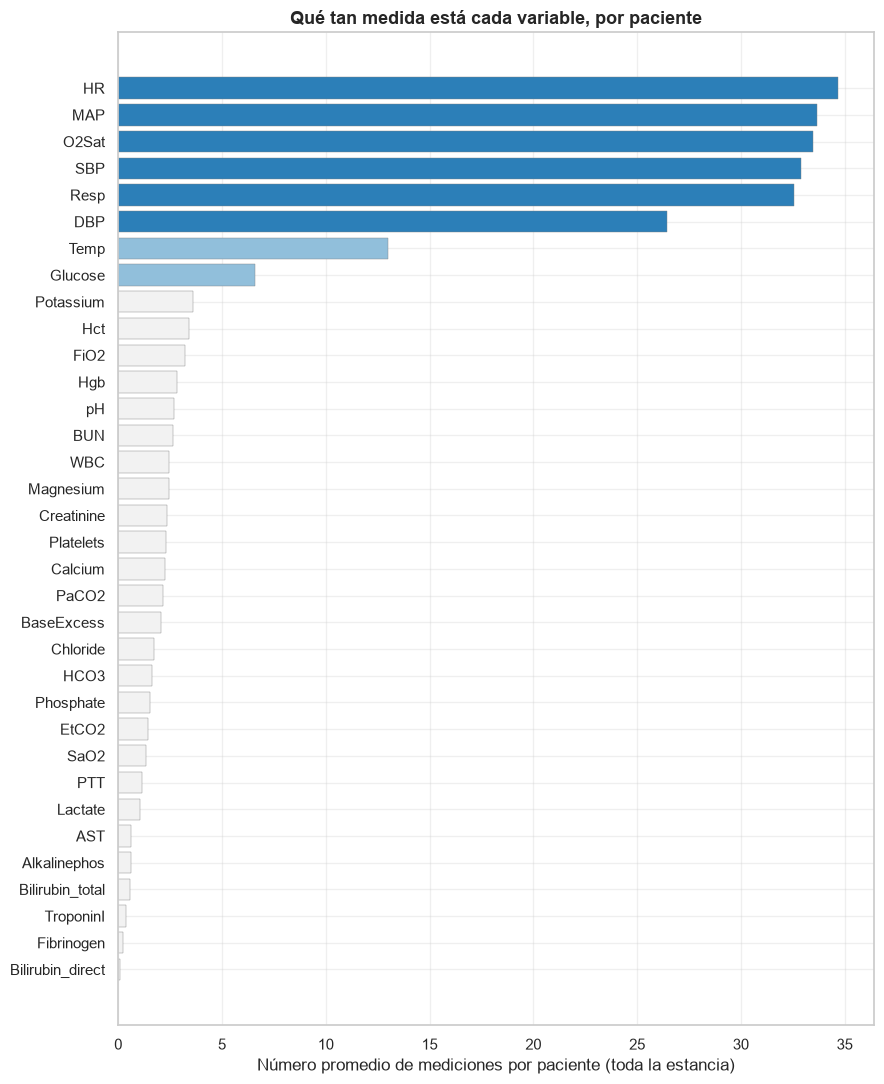

In [17]:
avg_medidas = df.groupby("pid", observed=True)[features.CLINICAS].count().mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 11))
colores = ["#2c7fb8" if v >= 20 else "#91bfdb" if v >= 5 else "#f2f2f2" for v in avg_medidas]
ax.barh(avg_medidas.index, avg_medidas.values, color=colores, edgecolor="grey", linewidth=0.3)
ax.set_xlabel("Número promedio de mediciones por paciente (toda la estancia)")
ax.set_title("Qué tan medida está cada variable, por paciente")
plt.tight_layout()
plt.show()

`HR` acumula **34,7 mediciones por paciente** en promedio (casi una por hora). En el extremo
opuesto, `Bilirubin_direct` apenas llega a **0,07**: la inmensa mayoría de los pacientes
**nunca** tiene ese laboratorio en toda su estancia — no es que se mida poco, es que casi no
se pide. Esa distinción entre "se mide poco" y "casi nunca se mide" importa para decidir, en
el notebook 04, si vale la pena construir features sobre una variable o directamente
descartarla.

## 8. Dónde están los huecos: matriz de disponibilidad y patrón de un paciente

Bajamos de la columna agregada a la fila individual. Tomamos una muestra de pacientes,
ordenamos sus filas por paciente y hora, y coloreamos cada celda según si esa variable se
midió (oscuro) o no (blanco) en esa hora exacta — el estilo de matriz que usa la librería
`missingno`, habitual para diagnosticar calidad de datos antes de modelar.

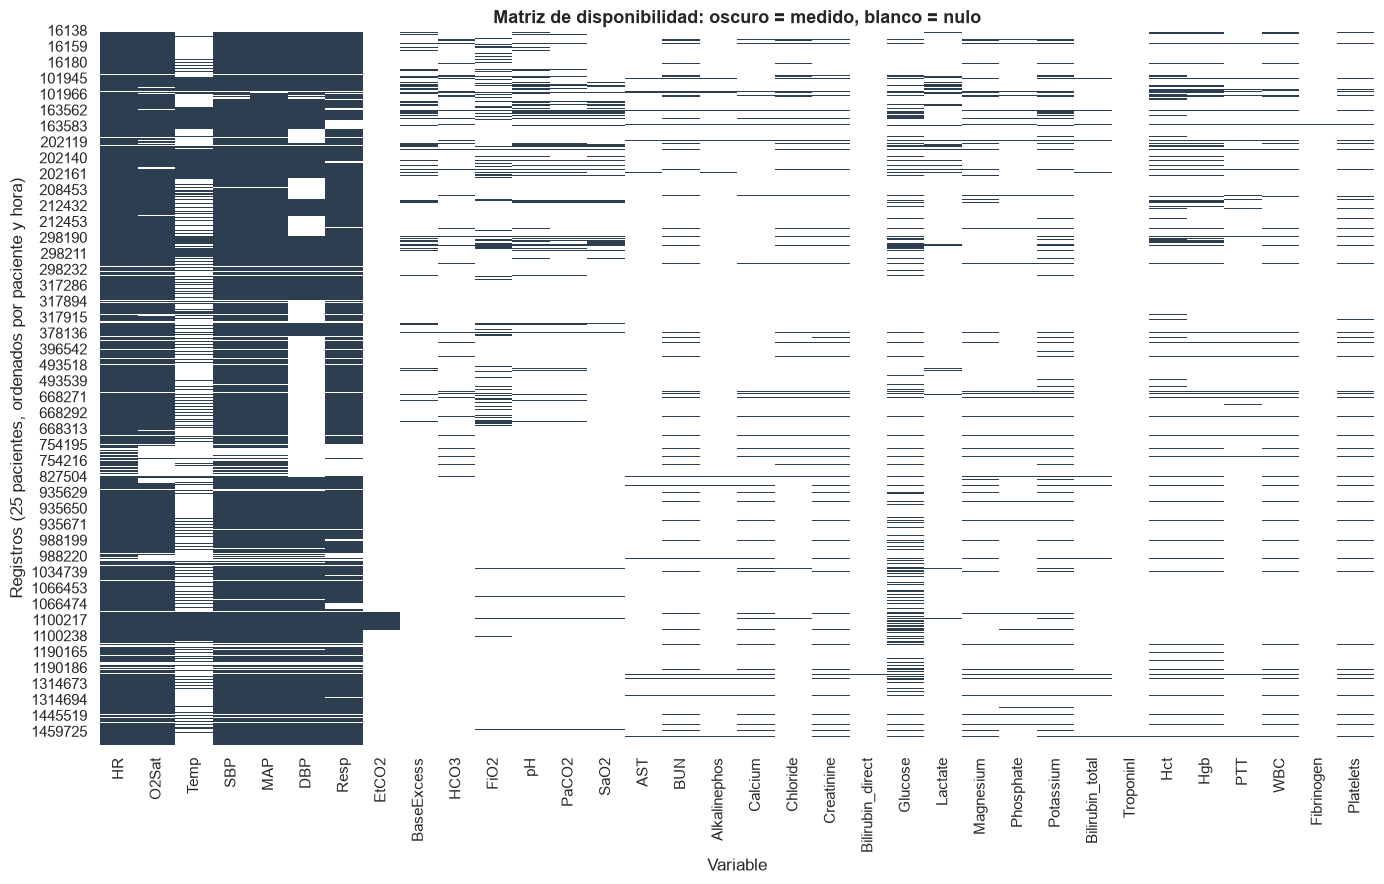

In [18]:
from matplotlib.colors import ListedColormap

muestra_pids = df["pid"].drop_duplicates().sample(25, random_state=3)
matriz = (df[df["pid"].isin(muestra_pids)]
          .sort_values(["pid", "ICULOS"])[features.VITALES + features.LABORATORIOS]
          .notna().astype(int))

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(matriz, cmap=ListedColormap(["white", "#2c3e50"]), cbar=False, ax=ax)
ax.set_xlabel("Variable")
ax.set_ylabel("Registros (25 pacientes, ordenados por paciente y hora)")
ax.set_title("Matriz de disponibilidad: oscuro = medido, blanco = nulo")
plt.tight_layout()
plt.show()

Las columnas de vitales (izquierda) forman franjas oscuras casi continuas; las de laboratorio
son puntos dispersos — coherente con la Sección 7. Lo nuevo que se ve aquí son las **bandas
horizontales que cruzan varias columnas de labs a la vez**: horas donde se pidió (o no se
pidió) un panel completo de una sola vez, no variable por variable.

Bajamos un nivel más: un solo paciente, con el detalle de qué se le midió en cada hora exacta
de su estancia. Elegimos uno séptico con una estancia de tamaño intermedio (45 horas), para
que se vea tanto la rutina como el cambio alrededor del evento.

Paciente p011251 (hospital A): 45 horas de estancia, sepsis declarada en la hora 36


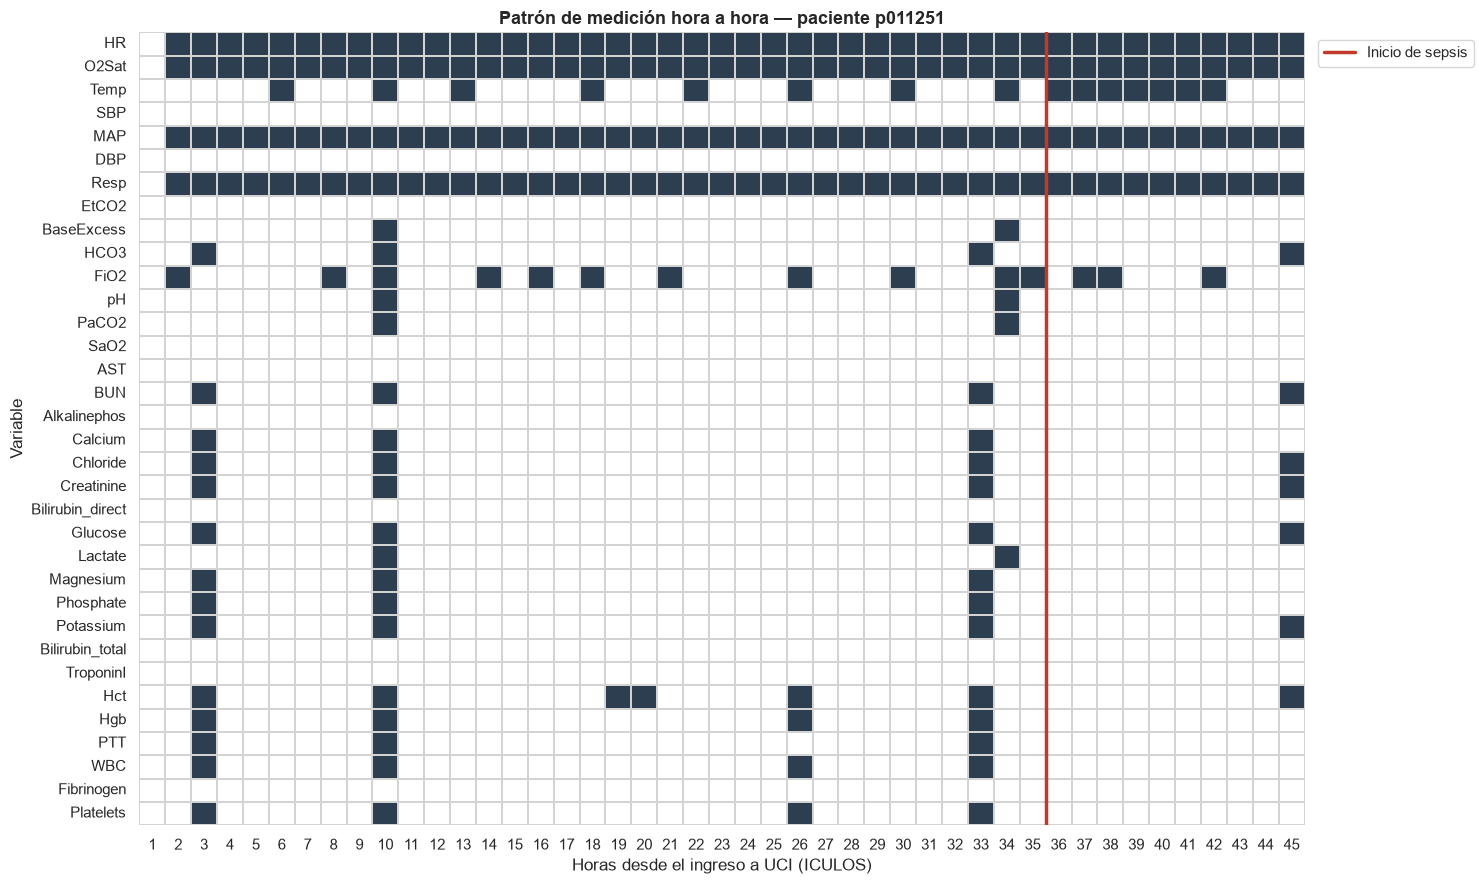

In [19]:
paciente_ejemplo = "p011251"
pe = df[df["pid"] == paciente_ejemplo].sort_values("ICULOS")
onset_pe = pe.loc[pe["SepsisLabel"] == 1, "ICULOS"].min()
print(f"Paciente {paciente_ejemplo} (hospital {pe.hosp.iloc[0]}): {len(pe)} horas de estancia, "
      f"sepsis declarada en la hora {onset_pe}")

medido = pe.set_index("ICULOS")[features.VITALES + features.LABORATORIOS].notna().T.astype(int)

fig, ax = plt.subplots(figsize=(15, 9))
sns.heatmap(medido, cmap=ListedColormap(["white", "#2c3e50"]), cbar=False,
            linewidths=0.3, linecolor="lightgrey", ax=ax)
ax.axvline(onset_pe - pe.ICULOS.min(), color=viz.COLOR_SEPSIS, lw=2.5, label="Inicio de sepsis")
ax.set_xlabel("Horas desde el ingreso a UCI (ICULOS)")
ax.set_ylabel("Variable")
ax.set_title(f"Patrón de medición hora a hora — paciente {paciente_ejemplo}")
ax.legend(loc="upper left", bbox_to_anchor=(1.005, 1.0))
plt.tight_layout()
plt.show()

La fila de vitales es casi sólida de punta a punta; las columnas de labs se agrupan en bandas
verticales (rondas de laboratorio) en vez de distribuirse al azar. Construyendo este ejemplo
encontramos algo que no esperábamos y que conviene dejar anotado, porque limita lo que
podremos hacer con las trayectorias de la Sección 9: en este paciente, igual que en casi
todos los sépticos del dataset, **el registro se corta apenas 9 horas después del inicio de
sepsis** (onset en la hora 36, última fila en la 45). Lo confirmamos a nivel de toda la
cohorte, no solo de este caso:

In [20]:
onset_todos = df[df.SepsisLabel == 1].groupby("pid", observed=True)["ICULOS"].min()
los_todos = df.groupby("pid", observed=True)["ICULOS"].max()
margen = los_todos.reindex(onset_todos.index) - onset_todos
margen.describe().round(1)

count    2932.0
mean        8.5
std         0.8
min         0.0
25%         8.0
50%         9.0
75%         9.0
max         9.0
Name: ICULOS, dtype: float64

Mediana de 9 horas, p25 = 8, p75 = 9: casi sin variación. El challenge truncó el registro de
cada paciente poco después de confirmar la sepsis, probablemente por diseño del dataset y no
porque el paciente egrese o fallezca justo en ese instante. **Consecuencia práctica**: en la
Sección 9 y en el notebook 03 no tiene sentido construir trayectorias más allá de +9 h después
del evento — a partir de ahí la muestra de pacientes con datos se desploma.

## 9. Trayectorias: cómo evolucionan los signos vitales antes del inicio de sepsis

La pregunta que motiva todo el modelado: si un signo vital sube o baja de forma consistente
en las horas *previas* al evento, es una señal de alerta temprana genuina. Alineamos a cada
paciente séptico respecto a su propia hora de inicio (hora 0 = onset) y promediamos.

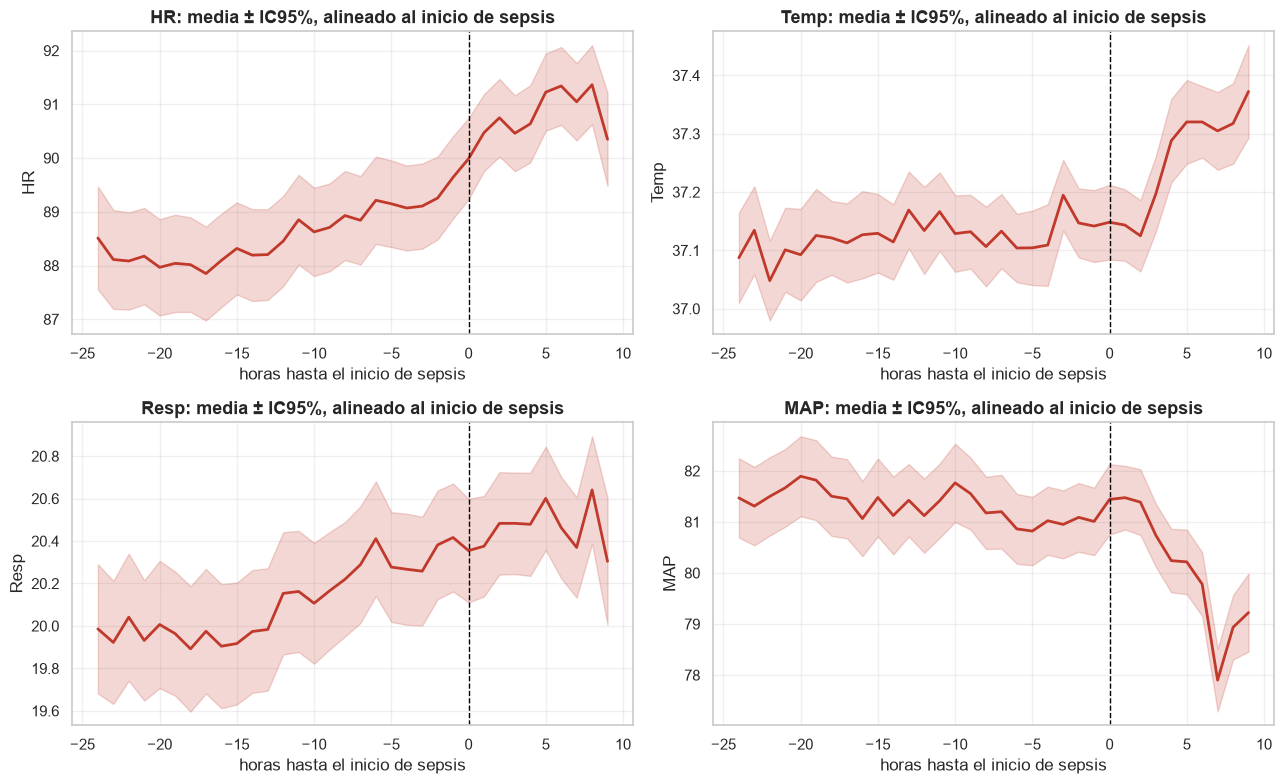

In [21]:
onset = df.loc[df.SepsisLabel == 1].groupby("pid", observed=True)["ICULOS"].min()
df["horas_hasta_sepsis"] = df["ICULOS"] - df["pid"].map(onset.reindex(df["pid"].cat.categories))

pacientes_septicos = df[df["pid"].isin(onset.index)]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, var in zip(axes.flat, ["HR", "Temp", "Resp", "MAP"]):
    viz.trayectoria_alineada(pacientes_septicos, var, ax=ax, ventana=(-24, 9))
    ax.set_title(f"{var}: media ± IC95%, alineado al inicio de sepsis")
plt.tight_layout()
plt.show()

El movimiento es real pero **modesto, no dramático** — y vale la pena decirlo así de honesto
en vez de forzar una lectura más limpia de lo que el dato muestra. `HR` sube de forma gradual
y sostenida: de 88,5 lpm en la hora −24 a 90,0 en la hora 0 y 91,3 en la hora +6 (+2,8 lpm en
30 horas). `Resp` sube un poco menos (20,0 → 20,4). `Temp` se mantiene prácticamente plana
hasta la hora +4, donde recién empieza a subir (37,1 → 37,3) — la fiebre llega tarde respecto
al resto de la señal, no antes. `MAP` es el más interesante: se mantiene estable **antes** del
evento (~81,5) y solo empieza a caer con claridad **después** (81,4 en la hora 0 → 79,8 en la
+6) — el deterioro hemodinámico se confirma más que se anticipa, en la misma línea que el
hallazgo de la Sección 8 sobre la carga de laboratorios.

Esto tiene una implicación directa para el modelado: si el promedio poblacional apenas se
mueve, la señal útil probablemente está más en la **tendencia individual de cada paciente**
(cuánto se aparta cada quien de su propio punto de partida) que en el valor absoluto
comparado contra la población — exactamente lo que capturan las features de pendiente y
desviación del basal que ya construimos en `src/features.py` (`dinamica_en_ventana`,
`desviacion_del_basal`), y que se explotan a fondo en el notebook 05.

## 10. Qué sabemos al cerrar este notebook

- **Dos escalas del target**: 1,80% de las horas son positivas, 7,27% de los pacientes lo son
  alguna vez. El proyecto se evalúa con métricas que entienden ambas (notebook 07).
- **La demografía casi no separa a los pacientes**: edad y género aportan poco. La señal va a
  tener que venir de la fisiología, no de quién es el paciente.
- **La sepsis no alarga la estancia típica, alarga su cola**: medianas casi iguales, percentil
  90 y 99 muy distintos. Cualquier resumen que solo reporte la media/mediana en este proyecto
  se queda corto — ya lo vimos con nuestros propios ojos.
- **Los tres relojes están relacionados**: llegar rápido a UCI tras el ingreso hospitalario se
  asocia a mayor riesgo, y la sepsis se declara en cualquier punto de la estancia, sin momento
  fijo — confirma que el problema debe resolverse hora a hora.
- **Ninguna variable aislada predice linealmente** (máxima correlación 0,134, y es `ICULOS`,
  no un signo vital). La señal está en la combinación y en la tendencia, no en el valor puntual.
- **A y B son poblaciones/sistemas distintos**, no la misma muestra partida en dos: A es más
  grave y llega más rápido a UCI, pero registra peor el tipo de unidad. Justifica la validación
  cruzada entre hospitales que aplicaremos en modelado.
- **Tres franjas de nulos**: vitales (<35%, arrastre suficiente), `Temp`/`Glucose` (intermedio)
  y 24 laboratorios (>90%, requieren estrategia distinta en el notebook 04).
- **La ausencia sigue un patrón de horas, no el azar**: se agrupa en bandas (paneles pedidos
  juntos) y el registro se corta ~9 horas después del inicio de sepsis en casi todos los
  pacientes — un límite duro para cualquier ventana temporal que construyamos después.
- **Las trayectorias son reales pero modestas**: `HR` y `Resp` suben gradualmente antes del
  evento; `MAP` cae con más claridad *después*. La señal fuerte va a estar en la tendencia
  individual de cada paciente, no en el promedio poblacional.